# NetColoc analysis of rare variants in Autism spectrum disorder (ASD) and Congenital Heart Disease (CHD)

Example of NetColoc workflow on genes associated with rare exome variants in ASD and CHD

**Some background:**

Here we introduce NetColoc, a tool which evaluates the extent to which two gene sets are related in network space, i.e. the extent to which they are colocalized in a molecular interaction network, and interrogates the underlying biological pathways and processes using multiscale community detection. This framework may be applied to any number of scenarios in which gene sets have been associated with a phenotype or condition, including rare and common variants within the same disease, genes associated with two comorbid diseases, genetically correlated GWAS phenotypes, GWAS across two different species, or gene expression changes after treatment with two different drugs, to name a few. NetColoc relies on a dual network propagation approach to identify the region of network space which is significantly proximal to both input gene sets, and as such is highly effective for small to medium input gene sets.



# _Obtain input gene sets and interactome_

## 1. Load required packages

In [ ]:
###Folder for Netcoloc is here:

#/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/NetColoc/example_notebooks


###Folder for CrossSpecies is here:

#/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/CrossSpeciesBMI/Notebooks

#with three ipynb scripts to follow

In [ ]:
#! pip install netcoloc
#! pip install cdapsutil


In [1]:
# load required packages
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pandas as pd
import re
import random

from IPython.display import display

import getpass
import ndex2

import json
import cdapsutil

from gprofiler import GProfiler
gp = GProfiler("MyToolName/0.1")

from scipy.stats import hypergeom
from scipy.stats import norm

# latex rendering of text in graphs
import matplotlib as mpl
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

sns.set(font_scale=1.4)

sns.set_style('white')

sns.set_style("ticks", {"xtick.major.size": 15, "ytick.major.size": 15})
plt.rcParams['svg.fonttype'] = 'none'

from datetime import datetime
import sys
%matplotlib inline

In [ ]:
#! wget https://github.com/idekerlab/ddot/archive/refs/heads/python3.zip 
#! unzip python3.zip 
#! pip install ddot-python3/
#! pip install --upgrade pip

In [2]:
# verify DDOT was installed
import ddot

from netcoloc import netprop_zscore, netprop, network_colocalization, validation


## 2. Select two gene sets of interest. Load gene sets from text files into python.


Identify two gene sets of interest. Gene sets should come from experimental data (not manual curation) to avoid bias. 

**Usage Note**: gene sets should be < 500 genes (propagation algorithm breaks down if seeded with larger sets). If your gene set is larger, only use the top 500 as seeds to the network propagation.



In [4]:
# set names of geneset 1 and geneset 2
# ------ customize this section based on your gene sets and how they should be labeled -------
d1_name='DEP'
d2_name='CCD_sept25'

In [5]:
# ------ customize this section based your input genesets -------
# # load DEP genes
D1_df = pd.read_csv('human_DEP_noMHC_seed_genes_header.txt')
D1_df.index = D1_df['gene']
print('Number of '+d1_name+' genes:', len(D1_df))
D1_genes = D1_df.index.tolist() # define rare variant genes to seed network propagation
print("First 5 genes:", D1_genes[0:5])

Number of DEP genes: 258
First 5 genes: ['MARCH10', 'RERE', 'ACTL8', 'EPHB2', 'TAL1']


In [6]:
# ------ customize this section based your input genesets -------

# load CCD genes
D2_df = pd.read_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/NetColoc/data/CCDgenes_sept25.txt')
D2_df.index = D2_df['gene']
print('Number of '+d2_name+' genes:', len(D2_df))
D2_genes = D2_df.index.tolist() # define rare variant genes to seed network propagation
print("First 5 genes:", D2_genes[0:5])

Number of CCD_sept25 genes: 81
First 5 genes: ['ADCY2', 'ADGRG1', 'AEBP2', 'ANTXR2', 'ARGLU1']


In [7]:
# Output the overlap between the two gene sets
print('Number of '+d1_name+' and '+d2_name+' genes overlapping:', len(np.intersect1d(D1_genes,D2_genes)))

# Create a dictionary for each geneset
seed_dict = {d1_name:D1_genes,d2_name:D2_genes}


Number of DEP and CCD_sept25 genes overlapping: 1


## 3. Select gene interaction network to use for the analysis.

Identify network UUID on NDEx (ndexbio.org) and use this to import to this Jupyter notebook. We recommend using PCNet as a starting point, but a user may want to switch to “STRING high confidence” if using a machine with low memory (< 8GB RAM).


In [8]:
#interactome_uuid='4de852d9-9908-11e9-bcaf-0ac135e8bacf' # for PCNet - 18820 nodes, 2693109 edges
#interactome_uuid='8b4b54fa-e87d-11ee-9621-005056ae23aa' # for PCNet2.2 - 18558 nodes, 3323928 edges

interactome_uuid='d73d6357-e87b-11ee-9621-005056ae23aa' # for PCNet2.0 Number of nodes: 19267 / Number of edges: 3852119

# interactome_uuid='275bd84e-3d18-11e8-a935-0ac135e8bacf' # for STRING high confidence
ndex_server='public.ndexbio.org'
ndex_user=None
ndex_password=None
G_int = ndex2.create_nice_cx_from_server(
            ndex_server, 
            username=ndex_user, 
            password=ndex_password, 
            uuid=interactome_uuid
        ).to_networkx()
nodes = list(G_int.nodes)

# remove self edges from network
G_int.remove_edges_from(nx.selfloop_edges(G_int))

# print out the numbers of nodes and edges in the interactome for diagnostic purposes:
print('Number of nodes:', len(G_int.nodes))
print('\nNumber of edges:', len(G_int.edges))

Number of nodes: 19267

Number of edges: 3852119


In [9]:
int_nodes = list(G_int.nodes)

# _Identify network colocalized gene network_

## 4. Precalculate matrices needed for propagation. This step should take a few minutes (more for larger/denser networks) 

A benchmarking analysis demonstrates that the runtime required scales with the number of edges (w’) and the number of nodes (w’’). NetColoc includes functionality for saving and loading these matrices, by setting the XXX parameter, which can be useful if running multiple analyses. The diffusion parameter, which controls the rate of propagation through the network, may be set in this step. In practice, we have found that results are not dependent on the choice of this parameter, and recommend using the default value of 0.5.

Background on network propagation: https://www.nature.com/articles/nrg.2017.38.pdf?origin=ppub


In [10]:
# pre-calculate matrices used for network propagation. this step takes a few minutes, more for denser interactomes
#print('\ncalculating w_prime')
#w_prime = netprop.get_normalized_adjacency_matrix(G_int, conserve_heat=True)

##print('\ncalculating w_double_prime')
#w_double_prime = netprop.get_individual_heats_matrix(w_prime, .5)

#w_double_prime can be saved to the file netcoloc_w_double_prime.npy
# in current working directory with the following call:
#np.save('netcoloc_w_double_prime_OCDext-noMHC_CCDv12.npy', w_double_prime)
#np.save('netcoloc_w_prime_OCDext-noMHC_CCDv12.npy', w_prime)

# and reloaded later with: SEEMS TO BE THE SAME FOR ALL, NOT INPUT GENE SPECIFIC
#print('\nload_saved_w_double_prime')
#w_double_prime = np.load('netcoloc_w_double_prime_OCDext-noMHC_CCDv12.npy')

###load the ones created in CrossSpecies instead:

w_double_prime = np.load('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/CrossSpeciesBMI/Notebooks/indiv_heats_OCDv4_CCDsept25.npy')
w_prime = np.load('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/CrossSpeciesBMI/Notebooks/w_prime_OCDv4_CCDsept25.npy')

# NOTE: Saving w_double_prime results in a several gigabyte file and
#       takes a minute or more to save and load


## 5. Subset seed genes to those found in the selected network. 

Only genes contained in the interaction network will be retained for downstream analysis. 


In [11]:
# subset seed genes to those found in interactome
print("Number of D1 genes:", len(D1_genes))
D1_genes = list(np.intersect1d(D1_genes,int_nodes))
print("Number of D1 genes in interactome:", len(D1_genes))

print("Number of D2 genes:", len(D2_genes))
D2_genes = list(np.intersect1d(D2_genes,int_nodes))
print("Number of D2 genes in interactome:", len(D2_genes))


Number of D1 genes: 258
Number of D1 genes in interactome: 232
Number of D2 genes: 81
Number of D2 genes in interactome: 80


## 6. Compute network proximity scores from both seed gene sets independently.

The network proximity scores include a correction for the degree distribution of the input gene sets. The runtime required for computing the network proximity scores increases linearly with the number of nodes in the underlying interaction network and with the size of the input gene list

In [12]:
# D1 network propagation - Do not rerun!
print('\nCalculating D1 z-scores: ')
z_D1, Fnew_D1, Fnew_rand_D1 = netprop_zscore.calculate_heat_zscores(w_double_prime, int_nodes, 
                                                                    dict(G_int.degree), 
                                                                    D1_genes, num_reps=1000,
                                                                    minimum_bin_size=100)
z_D1 = pd.DataFrame({'z':z_D1})
z_D1.sort_values('z',ascending=False).head()


Calculating D1 z-scores: 


  0%|          | 0/1000 [00:00<?, ?it/s]

,z
ASCC3,27.252360
IK,26.273547
FH,24.146029
SF3B1,24.092065
RANGAP1,23.945057


In [13]:
#save gene list with z scores
#z_D1.to_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/z_D1_DEP_z-scores_pcnet2.csv', header=True, index=True, encoding='utf-8')

In [14]:
## D1 load network z-scores:
z_D1 = pd.read_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/z_D1_DEP_z-scores_pcnet2.csv', sep =",", index_col=0)
z_D1.head()

,z
TGFBR1,-0.309583
TGFBR2,-0.011677
SMAD3,0.716108
TGFB1,-0.253185
SMAD2,-0.076404


In [14]:
# D2 network propagation - Do not rerun!
print('\nCalculating D2 z-scores: ')
z_D2, Fnew_D2, Fnew_rand_D2 = netprop_zscore.calculate_heat_zscores(w_double_prime, int_nodes, 
                                                                    dict(G_int.degree), 
                                                                    D2_genes, num_reps=1000,
                                                                    minimum_bin_size=100)
z_D2 = pd.DataFrame({'z':z_D2})
z_D2.sort_values('z',ascending=False).head()


Calculating D2 z-scores: 


  0%|          | 0/1000 [00:00<?, ?it/s]

,z
SERBP1,22.167413
UTP20,19.901945
EMC2,18.856482
PPA2,17.657511
ARGLU1,17.221897


In [15]:
#save gene list with z scores
#z_D2.to_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/z_D2_CCD_sept25_z-scores_pcnet2_250922.csv', header=True, index=True, encoding='utf-8')

In [15]:
## D1 load network z-scores:
z_D2 = pd.read_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/z_D2_CCD_sept25_z-scores_pcnet2_250922.csv', sep =",", index_col=0)
z_D2.head()

,z
TGFBR1,1.982328
TGFBR2,1.840874
SMAD3,1.081009
TGFB1,0.024607
SMAD2,1.267861


### Merge the lists of z-scores and make one with both plus the combined score:

In [ ]:
#in R:
require(tidyverse)
library(dplyr)
setwd("/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/")
dep <- read.csv("z_D1_DEP_z-scores_pcnet2.csv", sep= ",", header=T)
dep <- data.frame(gene = dep$X,  D1_z = dep$z) 
ccd <- read.csv("z_D2_CCD_sept25_z-scores_pcnet2_250922.csv", sep= ",", header=T)
ccd <- data.frame(gene = ccd$X,  D2_z = ccd$z)
dep_ccd <- full_join(ccd, dep,  by="gene")
head(dep_ccd)
dep_ccd$zcomb <- dep_ccd$D1_z*dep_ccd$D2_z
nrow(dep_ccd)
colnames(dep_ccd) <- c("gene", "NPS_r", "NPS_h", "NPS_hr")  #change col names NPS_r	NPS_h	NPS_hr
write.table(dep_ccd, file = "/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/CrossSpeciesBMI/Data/outputs/DEP_ccd_zcomb_z12.txt", sep = "\t", row.names = FALSE, quote = FALSE)

## 7. Build NetColoc subnetwork and evaluate for significant network colocalization. 

To build the NetColoc subnetwork we take the product of the two proximity vectors as follows:

$z_{coloc}=z_1 \times z_2$  

We then select genes for which $z_{coloc}$ is greater than a threshold ($z_{coloc}>3$ here, but can be set by the user), and the network proximity scores were individually larger than a nominal threshold ($z_1>1.5$, and $z_2>1.5$ here, but can be set by the user). The subnetwork comprising the genes and interactions meeting these criteria make up the network colocalization subnetwork. 

The authors have found that the default threshold values work well in practice, to find the set of genes which is proximal to both seed gene sets. Tuning them higher will lead to fewer false positives, but more false negatives. Similarly, tuning them lower will lead to more false positives, but fewer false negatives. Either may be warranted given the specifics of an experiment. 

The researcher may conduct a sensitivity analysis of these thresholds to select to find a balance between higher NetColoc enrichment score, but smaller network, and lower NetColoc enrichment score, but larger network. The function ‘network_colocalization.calculate_network_enrichment’ is provided to enable such a sensitivity analysis. In this function, the network colocalization score is computed for the gene set pair, based on the observed network overlap and expected network overlap, over a range of z-score thresholds. 

If gene sets are significantly colocalized, proceed with analysis. Gene sets which are not significantly colocalized in the network have no evidence for shared underlying pathways, and thus proceeding with analysis of the network intersection in this case is not likely to return meaningful results.



In [16]:
#I just changed the num_reps from 100 to 1000 for more stable outcome:
#OBS do not rerun!!! 

zlist = [2,3,4,5,9,12]
z12list = [1,1.5,2]
netcoloc_enrichment_df = network_colocalization.calculate_network_enrichment(z_D1,z_D2,
                                                                             zthresh_list = zlist,
                                                                             z12thresh_list=z12list,
                                                                             verbose=True)
netcoloc_enrichment_df.head(20)

z = 2
z12 = 1
size of network intersection = 862
observed size/ expected size = 1.9999071968818154
p = 2.1418201404524577e-122
z = 2
z12 = 1.5
size of network intersection = 523
observed size/ expected size = 2.5857806783348165
p = 1.156054334561269e-142
z = 2
z12 = 2
size of network intersection = 204
observed size/ expected size = 3.058470764617691
p = 1.891910897565732e-62
z = 3
z12 = 1
size of network intersection = 627
observed size/ expected size = 2.2424892703862658
p = 1.7646097125016127e-123
z = 3
z12 = 1.5
size of network intersection = 483
observed size/ expected size = 2.6033525575378644
p = 3.606433089143538e-165
z = 3
z12 = 2
size of network intersection = 204
observed size/ expected size = 3.0258083654701866
p = 2.493559750874457e-66
z = 4
z12 = 1
size of network intersection = 445
observed size/ expected size = 2.414410504042103
p = 1.3295544204263507e-118
z = 4
z12 = 1.5
size of network intersection = 384
observed size/ expected size = 2.7540701427239473
p = 2.33293579

,z_comb,z_12,observed_overlap,expected_overlap_mean,expected_overlap_std,empirical_p,obs_exp
0,2,1.0,862,431.02,18.341200,2.141820e-122,1.999907
1,2,1.5,523,202.26,12.625862,1.156054e-142,2.585781
2,2,2.0,204,66.70,8.252878,1.891911e-62,3.058471
3,3,1.0,627,279.60,14.718016,1.764610e-123,2.242489
4,3,1.5,483,185.53,10.870561,3.606433e-165,2.603353
5,3,2.0,204,67.42,7.957613,2.493560e-66,3.025808
6,4,1.0,445,184.31,11.273593,1.329554e-118,2.414411
7,4,1.5,384,139.43,11.637229,2.332936e-98,2.754070
8,4,2.0,204,66.45,8.432526,4.065468e-60,3.069977
9,5,1.0,325,130.83,9.835705,4.760987e-87,2.484140


In [17]:
#netcoloc_enrichment_df.to_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/netcoloc_enrichment_df_CCD_DEP.csv', header=True, index=True, encoding='utf-8')

In [18]:
netcoloc_enrichment_df = pd.read_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/netcoloc_enrichment_df_CCD_DEP.csv', sep =",", index_col=0)
netcoloc_enrichment_df.head()

,z_comb,z_12,observed_overlap,expected_overlap_mean,expected_overlap_std,empirical_p,obs_exp
0,2,1.0,862,431.02,18.341200,2.141820e-122,1.999907
1,2,1.5,523,202.26,12.625862,1.156054e-142,2.585781
2,2,2.0,204,66.70,8.252878,1.891911e-62,3.058471
3,3,1.0,627,279.60,14.718016,1.764610e-123,2.242489
4,3,1.5,483,185.53,10.870561,3.606433e-165,2.603353


### Select z thresholds, and plot the sizes of the observed and expected NetColoc subnetworks.

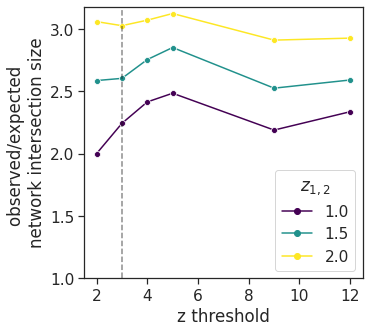

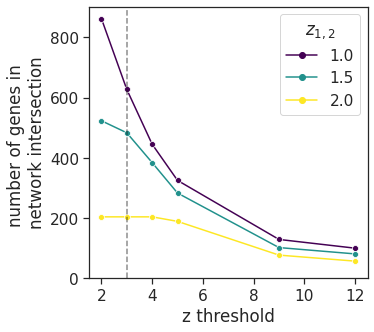

In [19]:
plt.figure(figsize=(5,5))
sns.lineplot(x='z_comb',y='obs_exp',data=netcoloc_enrichment_df,hue='z_12',style='z_12',
            markers=['o','o','o'],dashes=False,palette='viridis')
ylim_max=plt.gca().get_ylim()[1]
plt.ylim([1,ylim_max])
plt.plot([3,3],[1,ylim_max],'k--',alpha=.5)

plt.xlabel('z threshold')
plt.ylabel('observed/expected \nnetwork intersection size')
plt.legend(title="$z_{1,2}$")

plt.figure(figsize=(5,5))
sns.lineplot(x='z_comb',y='observed_overlap',data=netcoloc_enrichment_df,hue='z_12',style='z_12',
            markers=['o','o','o'],dashes=False,palette='viridis')

ylim_max=plt.gca().get_ylim()[1]
plt.ylim([0,ylim_max])
plt.plot([3,3],[0,ylim_max],'k--',alpha=.5)

plt.xlabel('z threshold')
plt.ylabel('number of genes in \nnetwork intersection')
plt.legend(title="$z_{1,2}$")

In [20]:
#save gene list with z scores and zcomb scores - save one more time...
netcoloc_enrichment_df.to_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/netcoloc_enrichment_df_DEP_CCD_sept25_pcnet2.csv', header=True, index=True, encoding='utf-8')

(-1.0, 2.0)

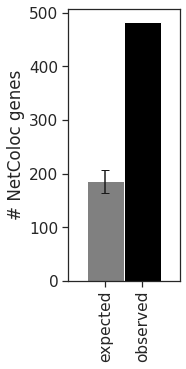

In [21]:
# ----------- select thresholds for NetColoc -----------------
zthresh=3 # default = 3
z12_thresh=1.5 # default = 1.5
# ------------------------------------------------------------

focal_netcoloc_enrichment = netcoloc_enrichment_df[(netcoloc_enrichment_df['z_comb']==zthresh) & \
                                                   (netcoloc_enrichment_df['z_12']==z12_thresh)].iloc[0]

# plot the observed and expected overlaps
plt.figure(figsize=(2,5))
plt.bar([0,1],[focal_netcoloc_enrichment['expected_overlap_mean'],
               focal_netcoloc_enrichment['observed_overlap']],color=['gray','black'],width=1)
plt.errorbar([0],[focal_netcoloc_enrichment['expected_overlap_mean']],
             [2*focal_netcoloc_enrichment['expected_overlap_std']],color='k',capsize=4)
plt.ylabel('# NetColoc genes')
plt.xticks([0,1],['expected','observed'],rotation='vertical')
plt.xlim([-1,2])

### Build network colocalization subnetwork based on selected thresholds

In [22]:
# select the genes in the network intersection, make a subgraph

G_overlap = network_colocalization.calculate_network_overlap_subgraph(G_int,z_D1['z'],z_D2['z'],z_score_threshold=zthresh,
                                                                     z1_threshold=z12_thresh,z2_threshold=z12_thresh)
print("Nodes in overlap subgraph:", len(G_overlap.nodes()))
print("Edges in overlap subgraph:", len(G_overlap.edges()))

Nodes in overlap subgraph: 483
Edges in overlap subgraph: 13782


## 8. Transform NetColoc subnetwork edges to cosine similarities (OPTIONAL)

Transform NetColoc subnetwork edges to cosine similarities, with the function ‘network_colocalization.transform_edges’. The cosine similarity score between two genes represents the extent to which those genes have similar interactors. In practice, the cosine similarity transformed score helps to visually reveal the underlying clustering structure present in a network. 



In [23]:
G_cosSim=network_colocalization.transform_edges(G_overlap,method='cosine_sim',edge_weight_threshold=0.95)

# _Compute network colocalized systems map_

## 9. Convert network colocalization subnetwork to form used in community detection module

In [24]:
# compile dataframe of metadata for overlapping nodes
node_df = pd.DataFrame(index=list(G_overlap.nodes))
node_df = node_df.assign(d1_seeds=0, d2_seeds=0, d1_name=d1_name, d2_name=d2_name)
node_df.loc[list(np.intersect1d(seed_dict[d1_name],node_df.index.tolist())), 'd1_seeds']=1
node_df.loc[list(np.intersect1d(seed_dict[d2_name],node_df.index.tolist())), 'd2_seeds']=1
node_df['z_d1']=z_D1.loc[list(G_overlap.nodes)]['z']
node_df['z_d2']=z_D2.loc[list(G_overlap.nodes)]['z']
node_df['z_both']=node_df['z_d1']*node_df['z_d2']
node_df['sum_seeds']=node_df['d1_seeds']+node_df['d2_seeds']

node_df = node_df.sort_values('z_both',ascending=False)
node_df.to_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/node_df_DEP_ccdsept25_pcnet2.csv', header=True, index=True, encoding='utf-8')


In [25]:
node_df.head(10)

,d1_seeds,d2_seeds,d1_name,d2_name,z_d1,z_d2,z_both,sum_seeds
CELF4,1,1,DEP,CCD_sept25,7.261359,9.273386,67.337386,2
RHOA,1,0,DEP,CCD_sept25,15.037273,3.407371,51.237570,1
ANKHD1-EIF4EBP3,1,0,DEP,CCD_sept25,14.429391,3.444616,49.703706,1
NTRK2,0,1,DEP,CCD_sept25,3.771769,11.876401,44.795046,1
DLG2,0,1,DEP,CCD_sept25,4.117727,10.337930,42.568775,1
GRM7,0,1,DEP,CCD_sept25,3.098640,12.125720,37.573245,1
CDH8,0,1,DEP,CCD_sept25,3.878752,9.431240,36.581446,1
FCF1,1,0,DEP,CCD_sept25,12.069143,2.805235,33.856783,1
GRM8,1,0,DEP,CCD_sept25,14.325804,2.355341,33.742155,1
SGIP1,1,0,DEP,CCD_sept25,9.939763,3.370799,33.504944,1


## 10. Run community detection on NetColoc subnetwork (recommend HiDef).

Documentation for CDAPS utils to build multiscale systems map in notebook

https://cdapsutil.readthedocs.io/en/latest/quicktutorial.html#example  
https://cdapsutil.readthedocs.io/en/latest/cdapsutil.html#community-detection  

In [26]:
print("Nodes in overlap subgraph:", len(G_overlap.nodes()))
print("Edges in overlap subgraph:", len(G_overlap.edges()))
# Create cx format of overlap subgraph
G_overlap_cx = ndex2.create_nice_cx_from_networkx(G_overlap)
G_overlap_cx.set_name(d1_name+'_'+d2_name+'_NetColoc_subgraph') 
for node_id, node in G_overlap_cx.get_nodes():
    data = node_df.loc[node['n']]
    for row, value in data.items():
        if row == 'd1_seeds' or row == 'd2_seeds' or row=='sum_seeds':
            data_type = 'double'
        elif row=='d1_name' or row=='d2_name':
            data_type='string'
        else:
            data_type = 'double'
        G_overlap_cx.set_node_attribute(node_id, row, value, type=data_type)

cd = cdapsutil.CommunityDetection()

# Run HiDeF on CDAPS REST service
G_hier = cd.run_community_detection(G_overlap_cx, algorithm='hidefv1.1beta',arguments={'--maxres':'20'})


Nodes in overlap subgraph: 483
Edges in overlap subgraph: 13782


In [27]:
print('Hierarchy name: ' + str(G_hier.get_name()))
print('# nodes: ' + str(len(G_hier.get_nodes())))
print('# edges: ' + str(len(G_hier.get_edges())))

Hierarchy name: hidefv1.1beta_(none)_DEP_CCD_sept25_NetColoc_subgraph
# nodes: 59
# edges: 64


In [ ]:
# sr = cdapsutil.ServiceRunner()
# sr.get_algorithms() # this will print out available options for each algorithm

## 11. Convert the NetColoc hierarchy to networkx format, and write out features of the hierarchy to a pandas dataframe, for easier access in Python.


In [28]:

G_hier = G_hier.to_networkx(mode='default')
G_hier

nodes = G_hier.nodes()

# print the number of nodes and edges in the hierarchy for diagnostic purposes
print('Number of nodes:', len(G_hier.nodes()))

print('\nNumber of edges:', len(G_hier.edges()))



Number of nodes: 59

Number of edges: 64


In [29]:
G_hier_df = pd.DataFrame.from_dict(dict(G_hier.nodes(data=True)), orient="index")
G_hier_df.to_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/NetColoc/example_notebooks/DEP_CCD_Network_hierarchy_data.tsv', sep="\t")


In [30]:
# add node attributes to dataframe for easier access
hier_df = pd.DataFrame.from_dict(dict(G_hier.nodes(data=True)), orient='index')
hier_df['system_ID']=hier_df.index.tolist()
# some columns are not the right type
hier_df['CD_MemberList_Size']=[int(x) for x in hier_df['CD_MemberList_Size'].tolist()]
hier_df['HiDeF_persistence']=[int(x) for x in hier_df['HiDeF_persistence'].tolist()]
hier_df.head(5)

,CD_MemberList,CD_MemberList_Size,CD_Labeled,CD_MemberList_LogSize,CD_CommunityName,CD_AnnotatedMembers,CD_AnnotatedMembers_Size,CD_AnnotatedMembers_Overlap,CD_AnnotatedMembers_Pvalue,HiDeF_persistence,represents,name,system_ID
0,GLIPR1 TENM2 CLTRN GPM6A KIRREL3 DENND1B MAP9 ...,475,False,8.892,,,0,0.0,0.0,126,C483,C483,0
1,ZNF608 TNNI3K CADM2 FAIM2 GNPDA2 NXPH1 NRXN3,7,False,2.807,,,0,0.0,0.0,19,C513,C513,1
2,DENND1C NLGN4X PDE4D TNR DLGAP2 GNAO1 DISC1 GP...,221,False,7.788,,,0,0.0,0.0,17,C484,C484,2
3,DENND1C GLIPR1 LRRN1 TTC9C TENM2 CDH6 SEMA3E E...,183,False,7.516,,,0,0.0,0.0,7,C485,C485,3
4,PDZD2 PARD3B MAGI2 KIRREL3 NPHS1 KIRREL2,6,False,2.585,,,0,0.0,0.0,5,C517,C517,4


## 12. Do not remove systems with no seed genes

In [31]:
hier_df.index=hier_df['name']
hier_df.head()

num_d1_seeds, num_d2_seeds, num_both_seeds = [],[],[]
frac_d1_seeds, frac_d2_seeds, frac_both_seeds=[],[],[]

systems_keep = []
for c in hier_df.index.tolist():
    system_genes = hier_df['CD_MemberList'].loc[c].split(' ')
    d1_temp = list(np.intersect1d(system_genes,seed_dict[d1_name]))
    d2_temp = list(np.intersect1d(system_genes,seed_dict[d2_name]))
    num_d1_temp = len(d1_temp)
    num_d2_temp = len(d2_temp)
    if (num_d1_temp+num_d2_temp)>=0: # keep the system if it has at least 1 seed gene KT changed!!!
        systems_keep.append(c)
        num_both_temp = len(np.intersect1d(d1_temp,d2_temp))
        num_both_seeds.append(num_both_temp)
        num_d1_seeds.append(num_d1_temp-num_both_temp)
        num_d2_seeds.append(num_d2_temp-num_both_temp)
        
        frac_both_seeds.append(num_both_temp/float(len(system_genes)))
        frac_d1_seeds.append((num_d1_temp-num_both_temp)/float(len(system_genes)))
        frac_d2_seeds.append((num_d2_temp-num_both_temp)/float(len(system_genes)))

        
frac_no_seeds = np.subtract(1.0,np.array([frac_d1_seeds,frac_d2_seeds,frac_both_seeds]).sum(axis=0))

hier_df = hier_df.loc[systems_keep]
hier_df['num_d1_seeds']=num_d1_seeds
hier_df['num_d2_seeds']=num_d2_seeds
hier_df['num_both_seeds']=num_d2_seeds
hier_df['frac_d1_seeds']=frac_d1_seeds
hier_df['frac_d2_seeds']=frac_d2_seeds
hier_df['frac_both_seeds']=frac_both_seeds
hier_df['frac_no_seeds']=frac_no_seeds
print("Number of nodes with seed genes:", len(hier_df)) #changed to all nodes here.

hier_df.head()
    

Number of nodes with seed genes: 59


,CD_MemberList,CD_MemberList_Size,CD_Labeled,CD_MemberList_LogSize,CD_CommunityName,CD_AnnotatedMembers,CD_AnnotatedMembers_Size,CD_AnnotatedMembers_Overlap,CD_AnnotatedMembers_Pvalue,HiDeF_persistence,represents,name,system_ID,num_d1_seeds,num_d2_seeds,num_both_seeds,frac_d1_seeds,frac_d2_seeds,frac_both_seeds,frac_no_seeds
name,,,,,,,,,,,,,,,,,,,,
C483,GLIPR1 TENM2 CLTRN GPM6A KIRREL3 DENND1B MAP9 ...,475,False,8.892,,,0,0.0,0.0,126,C483,C483,0,49,21,21,0.103158,0.044211,0.002105,0.850526
C513,ZNF608 TNNI3K CADM2 FAIM2 GNPDA2 NXPH1 NRXN3,7,False,2.807,,,0,0.0,0.0,19,C513,C513,1,0,1,1,0.000000,0.142857,0.000000,0.857143
C484,DENND1C NLGN4X PDE4D TNR DLGAP2 GNAO1 DISC1 GP...,221,False,7.788,,,0,0.0,0.0,17,C484,C484,2,16,7,7,0.072398,0.031674,0.000000,0.895928
C485,DENND1C GLIPR1 LRRN1 TTC9C TENM2 CDH6 SEMA3E E...,183,False,7.516,,,0,0.0,0.0,7,C485,C485,3,23,10,10,0.125683,0.054645,0.005464,0.814208
C517,PDZD2 PARD3B MAGI2 KIRREL3 NPHS1 KIRREL2,6,False,2.585,,,0,0.0,0.0,5,C517,C517,4,0,1,1,0.000000,0.166667,0.000000,0.833333


In [32]:
# prune G_hier--> only keep systems with at least one seed gene

nkeep=[]
for n in list(G_hier.nodes()):
    if G_hier.nodes(data=True)[n]['name'] in systems_keep:
        nkeep.append(n)
        

G_hier = nx.subgraph(G_hier, nkeep)
print("Number of nodes with seed genes:", len(G_hier.nodes()))
print("Number of edges remaining:", len(G_hier.edges()))

Number of nodes with seed genes: 59
Number of edges remaining: 64


## 13. Sneak peek of hierarchy visualization (OPTIONAL)

In [ ]:
#network_colocalization.view_G_hier(G_hier)

## 14. Annotate systems with gprofiler. 

Annotate moderately sized systems (between 50 to 1000 genes per system) if they are significantly enriched for a Gene Ontology biological process. Also require that the GO term is enriched with $p<10^{-5}$ and shares at least 3 genes with the system to annotate, to increase the stringency of the annotation. Label the system using the GO term that meets these criteria, and has the highest sum of precision and recall. Systems which have no GO terms meeting these criteria are labeled with their unique system ID.


In [33]:
# gprofiler annotation of clusters

system_name_list = []
for p in hier_df.index.tolist():
    focal_genes=hier_df['CD_MemberList'].loc[p].split(' ')
    print(p)
    print(len(focal_genes))
    if len(focal_genes)>2:
        gp_temp = pd.DataFrame(gp.profile(focal_genes,significance_threshold_method='fdr',
                                               sources=['REAC']))
        if len(gp_temp)>0: # make sure data is not empty
            
            # make sure terms are specific, and overlap with at least 3 genes
            gp_temp = gp_temp[(gp_temp['term_size']<1000)&(gp_temp['term_size']>50)] 
            gp_temp = gp_temp[gp_temp['intersection_size']>=3]
            
            gp_temp = gp_temp[gp_temp['p_value']<1E-3] # set a stringent p-value threshold - KT changed from 1E-5
            
            gp_temp = gp_temp.sort_values('recall',ascending=False)
            
            if len(gp_temp)>1:
                system_name_list.append(gp_temp.head(1)['name'].tolist()[0])
            else:
                system_name_list.append(p)
        else:
            system_name_list.append(p)
            

        display(gp_temp.head())
        
    else:
        system_name_list.append(p)

C483
475


,description,effective_domain_size,intersection_size,name,native,p_value,parents,precision,query,query_size,recall,significant,source,term_size
1,Heparan sulfate/heparin (HS-GAG) metabolism,11004,37,Heparan sulfate/heparin (HS-GAG) metabolism,REAC:R-HSA-1638091,1.712118e-41,[REAC:R-HSA-1630316],0.118211,query_1,313,0.649123,True,REAC,57
16,Neurexins and neuroligins,11004,20,Neurexins and neuroligins,REAC:R-HSA-6794361,7.688564e-16,[REAC:R-HSA-6794362],0.063898,query_1,313,0.357143,True,REAC,56
4,Glycosaminoglycan metabolism,11004,40,Glycosaminoglycan metabolism,REAC:R-HSA-1630316,1.475191e-29,[REAC:R-HSA-71387],0.127796,query_1,313,0.320000,True,REAC,125
8,Protein-protein interactions at synapses,11004,27,Protein-protein interactions at synapses,REAC:R-HSA-6794362,1.492293e-19,[REAC:R-HSA-112316],0.086262,query_1,313,0.313953,True,REAC,86
21,GABA receptor activation,11004,16,GABA receptor activation,REAC:R-HSA-977443,1.758050e-10,[REAC:R-HSA-112314],0.051118,query_1,313,0.266667,True,REAC,60


C513
7


,description,effective_domain_size,intersection_size,name,native,p_value,parents,precision,query,query_size,recall,significant,source,term_size


C484
221


...

,description,effective_domain_size,intersection_size,name,native,p_value,parents,precision,query,query_size,recall,significant,source,term_size


C541
3


,description,effective_domain_size,intersection_size,name,native,p_value,parents,precision,query,query_size,recall,significant,source,term_size


C539
4


,description,effective_domain_size,intersection_size,name,native,p_value,parents,precision,query,query_size,recall,significant,source,term_size


# _Validate identified genes and systems_

## 15. Load and parse mouse variant database

Requires DDOT for ontology parsing https://github.com/michaelkyu/ddot/blob/master/examples/Tutorial.ipynb

Parse the ontology, data from http://www.informatics.jax.org/vocab/mp_ontology


In [34]:
mgi_df = validation.load_MGI_mouseKO_data()
mgi_df.head()

INFO:biothings.client:querying 1-1000...
INFO:biothings.client:done.
INFO:biothings.client:querying 1001-2000...
INFO:biothings.client:done.
INFO:biothings.client:querying 2001-3000...
INFO:biothings.client:done.
INFO:biothings.client:querying 3001-4000...
INFO:biothings.client:done.
INFO:biothings.client:querying 4001-5000...
INFO:biothings.client:done.
INFO:biothings.client:querying 5001-6000...
INFO:biothings.client:done.
INFO:biothings.client:querying 6001-7000...
INFO:biothings.client:done.
INFO:biothings.client:querying 7001-8000...
INFO:biothings.client:done.
INFO:biothings.client:querying 8001-9000...
INFO:biothings.client:done.
INFO:biothings.client:querying 9001-10000...
INFO:biothings.client:done.
INFO:biothings.client:querying 10001-11000...
INFO:biothings.client:done.
INFO:biothings.client:querying 11001-12000...
INFO:biothings.client:done.
INFO:biothings.client:querying 12001-13000...
INFO:biothings.client:done.
INFO:biothings.client:querying 13001-14000...
INFO:biothings

26031
13233
13203


,MGI_Allele_Accession_ID,Allele symbol,involves,MP,PMID,MGI_marker_accession_ID,gene_name,human_ortholog
gene_name,,,,,,,,
Rb1,Rb1<tm1Tyj>/Rb1<tm1Tyj>,Rb1<tm1Tyj>,involves: 129S2/SvPas,MP:0000600,12529408,MGI:97874,Rb1,RB1
Rb1,Rb1<tm1Tyj>/Rb1<tm1Tyj>,Rb1<tm1Tyj>,involves: 129S2/SvPas,MP:0001716,16449662,MGI:97874,Rb1,RB1
Rb1,Rb1<tm1Tyj>/Rb1<tm1Tyj>,Rb1<tm1Tyj>,involves: 129S2/SvPas,MP:0001698,16449662,MGI:97874,Rb1,RB1
Rb1,Rb1<tm1Tyj>/Rb1<tm1Tyj>,Rb1<tm1Tyj>,involves: 129S2/SvPas,MP:0001092,16449662,MGI:97874,Rb1,RB1
Rb1,Rb1<tm1Tyj>/Rb1<tm1Tyj>,Rb1<tm1Tyj>,involves: 129S2/SvPas,MP:0000961,16449662,MGI:97874,Rb1,RB1


In [35]:
MPO = validation.load_MPO()
MPO

15609


,description
MP,
MP:0000001,mammalian phenotype
MP:0000002,obsolete Morphology
MP:0000003,abnormal adipose tissue morphology
MP:0000011,abnormal adipose tissue morphology
MP:0000005,increased brown adipose tissue amount


,Parent,Child,Relation,Namespace
0,MP:0005375,MP:0000003,is_a,MPheno.ontology
1,MP:0001778,MP:0000005,is_a,MPheno.ontology
2,MP:0001781,MP:0000008,is_a,MPheno.ontology
3,MP:0005334,MP:0000010,is_a,MPheno.ontology
4,MP:0000003,MP:0000013,is_a,MPheno.ontology


0 genes, 14469 terms, 0 gene-term relations, 19031 term-term relations
node_attributes: ['description']
edge_attributes: ['Relation', 'Namespace']

## 16. Identify phenotype(s) of interest. 

Recommend including a negative control, a phenotype that is not expected to overlap with the two phenotypes of interest.

### Here we find MPO terms related to brain or heart

Modify as needed for each specific project

In [36]:
def get_MP_description(term_id, ontology=MPO):
    return ontology.node_attr.loc[term_id, "description"]

In [37]:
# find terms related to brain
# ---- modify this part as needed for your project -----
MP_focal_brain_list = []
for t in MPO.node_attr.index.tolist():
    descr_temp = MPO.node_attr.loc[t]['description']
    if descr_temp.find('nervous')>-1:
        MP_focal_brain_list.append(t)
    elif descr_temp.find('neuron')>-1:
        MP_focal_brain_list.append(t)
    elif descr_temp.find('synapt')>-1:
        MP_focal_brain_list.append(t)
        
print("Number of brain phenotypes", len(MP_focal_brain_list))
print("Example brain phenotypes:")
print("\n".join([mp+" - "+get_MP_description(mp) for mp in MP_focal_brain_list[0:10]]))

Number of brain phenotypes 245
Example brain phenotypes:
MP:0000778 - abnormal nervous system tract morphology
MP:0000811 - hippocampal neuron degeneration
MP:0000937 - abnormal motor neuron morphology
MP:0000938 - motor neuron degeneration
MP:0000939 - decreased motor neuron number
MP:0000940 - abnormal motor neuron innervation pattern
MP:0000958 - peripheral nervous system degeneration
MP:0000965 - abnormal sensory neuron morphology
MP:0000966 - decreased sensory neuron number
MP:0000968 - abnormal sensory neuron innervation pattern


## 17. Compute the enrichment of selected phenotype(s) in NetColoc subnetwork as a whole.

By computing the enrichment in the entire NetColoc subnetwork, we identify the phenotypes with the strongest association with the entire set of genes identified to be related to both input sets.

In [38]:
# add a negative control phenotype: abnormal innate immunity: MP:0002419
# negative controls are tough here because we're dealing with development, which impacts almost everything.
MP_focal_list = ['MP:0002419']+MP_focal_brain_list
root_KO_brain_df=validation.MPO_enrichment_root(hier_df,MPO,mgi_df,MP_focal_list,G_int,verbose=True)


abnormal innate immunity
number of genes in root node = 475
number of genes in focal MPO term = 663
number overlapping genes = 9
0.06543944739150226
(-1.2885010630339546, 0.03989317455572883)
-0.624303944239113

abnormal nervous system tract morphology
number of genes in root node = 475
number of genes in focal MPO term = 251
number overlapping genes = 34
4.2266056961899185e-23
(1.5133536343982001, 2.260626696031432)
1.886990165214816

hippocampal neuron degeneration
number of genes in root node = 475
number of genes in focal MPO term = 28
number overlapping genes = 2
0.12914811516670516
(-0.32535481814760936, 2.5568693279406602)
1.1157572548965256

abnormal motor neuron morphology
number of genes in root node = 475
number of genes in focal MPO term = 177
number overlapping genes = 17
1.6797531989949e-08
(0.9553074605411158, 1.9723048520036475)
1.4638061562723816

motor neuron degeneration
number of genes in root node = 475
number of genes in focal MPO term = 47
number overlapping gen

In [39]:
#no heart to merge, just create the df:
root_KO_brain_df['MPO_term_type']='brain'
root_KO_df = root_KO_brain_df.sort_values('OR_p')
root_KO_df.loc['MP:0002419','MPO_term_type'] = 'neg_ctrl'
root_KO_df.head()
root_KO_df['MPO_term_type'].value_counts()

brain       130
neg_ctrl      1
Name: MPO_term_type, dtype: int64

In [40]:
root_KO_df['MPO_term_type'].value_counts()

brain       130
neg_ctrl      1
Name: MPO_term_type, dtype: int64

## 18. Compute the enrichment of phenotype(s) in NetColoc subsystems.

Some phenotypes may have stronger associations with NetColoc subsystems than with the root node. In this step we calculate the enrichment of selected phenotypes in each NetColoc subsystem.


In [41]:
MP_focal_top = root_KO_df.head(10).index.tolist() # record the top 10 overall
MP_full_results_df = validation.MPO_enrichment_full(hier_df,MPO,mgi_df,MP_focal_top,G_int)
MP_full_results_df.head()

abnormal synaptic physiology
Genes and Terms to keep: 101
abnormal synaptic transmission
Genes and Terms to keep: 96
abnormal CNS synaptic transmission
Genes and Terms to keep: 64
abnormal neuron morphology
Genes and Terms to keep: 335
abnormal excitatory postsynaptic currents
Genes and Terms to keep: 12
abnormal nervous system electrophysiology
Genes and Terms to keep: 43
abnormal inhibitory postsynaptic currents
Genes and Terms to keep: 4
abnormal miniature excitatory postsynaptic currents
Genes and Terms to keep: 7
abnormal synaptic depression
Genes and Terms to keep: 6
abnormal excitatory postsynaptic potential


,abnormal synaptic physiology:-log(OR_p),abnormal synaptic physiology:log_OR,abnormal synaptic physiology:num_genes,abnormal synaptic physiology:gene_ids,abnormal synaptic transmission:-log(OR_p),abnormal synaptic transmission:log_OR,abnormal synaptic transmission:num_genes,abnormal synaptic transmission:gene_ids,abnormal CNS synaptic transmission:-log(OR_p),abnormal CNS synaptic transmission:log_OR,...,abnormal miniature excitatory postsynaptic currents:num_genes,abnormal miniature excitatory postsynaptic currents:gene_ids,abnormal synaptic depression:-log(OR_p),abnormal synaptic depression:log_OR,abnormal synaptic depression:num_genes,abnormal synaptic depression:gene_ids,abnormal excitatory postsynaptic potential:-log(OR_p),abnormal excitatory postsynaptic potential:log_OR,abnormal excitatory postsynaptic potential:num_genes,abnormal excitatory postsynaptic potential:gene_ids
C483,97.715219,2.168707,156,ADCY1 ADCY2 ADCY8 ADGRB3 ANK2 APBA1 ARIH1 ATP2...,95.958625,2.155939,154,ADCY1 ADCY2 ADCY8 ADGRB3 ANK2 APBA1 ARIH1 ATP2...,94.522700,2.177263,...,34,ADCY1 ADCY2 ANK2 CACNA1A CACNA1B CACNG3 CADPS ...,36.483627,2.686656,32,ADCY8 ADGRB3 BSN CAMK2A CAMK2B CNR1 CSPG5 DISC...,32.857471,2.660979,29,ADCY1 BDNF CACNA1A CACNA1B CAMK2A CDH2 CHRNA3 ...
C513,0.429630,0.964943,1,NRXN3,0.433933,0.972365,1,NRXN3,0.489889,1.066469,...,1,NRXN3,2.573567,3.255435,1,NRXN3,-0.000000,0.000000,0,
C484,108.593772,3.090973,123,ADCY1 ADCY2 ADCY8 ADGRB3 ANK2 APBA1 ATP2B2 BDN...,107.988632,3.079878,122,ADCY1 ADCY2 ADCY8 ADGRB3 ANK2 APBA1 ATP2B2 BDN...,105.057051,3.030477,...,29,ADCY1 ADCY2 ANK2 CACNA1A CACNA1B CACNG3 CADPS ...,46.330883,3.302774,27,ADCY8 ADGRB3 BSN CAMK2A CAMK2B CNR1 DISC1 DRD2...,38.221835,3.186191,23,ADCY1 BDNF CACNA1A CACNA1B CAMK2A CHRNA3 CNR1 ...
C485,4.684295,0.925645,25,ARIH1 CDH2 CELF4 CLCN1 CLSTN1 DAPK1 DPP6 EPHA4...,4.202936,0.885140,24,ARIH1 CDH2 CELF4 CLCN1 CLSTN1 DAPK1 DPP6 EPHA4...,5.031968,0.981198,...,5,CDH2 CELF4 EPHA4 GRIN1 NRXN3,1.852026,1.261715,4,NR2F1 NRXN3 PCDH17 RBFOX3,6.053308,1.953580,7,CDH2 CLSTN1 JPH3 MBNL2 OLIG2 RBFOX3 SEMA3E
C517,-0.000000,0.000000,0,,-0.000000,0.000000,0,,-0.000000,0.000000,...,0,,-0.000000,0.000000,0,,-0.000000,0.000000,0,


In [42]:
print("Top ten terms:")
print("\n".join([mp+" - "+get_MP_description(mp) for mp in MP_focal_top]))

Top ten terms:
MP:0021009 - abnormal synaptic physiology
MP:0003635 - abnormal synaptic transmission
MP:0002206 - abnormal CNS synaptic transmission
MP:0002882 - abnormal neuron morphology
MP:0002910 - abnormal excitatory postsynaptic currents
MP:0002272 - abnormal nervous system electrophysiology
MP:0002945 - abnormal inhibitory postsynaptic currents
MP:0004753 - abnormal miniature excitatory postsynaptic currents
MP:0002915 - abnormal synaptic depression
MP:0002912 - abnormal excitatory postsynaptic potential


## 19. Annotate the NetColoc systems map with mouse variant data, input genes, and enriched GO terms

In [43]:
# add the best gprofiler annotation
MP_full_results_df['gprofiler_name']=pd.Series(system_name_list,index=hier_df.index.tolist())
# don't annotate the root node
root_node = hier_df['CD_MemberList_Size'].sort_values(ascending=False).head(1).index.tolist()[0]
MP_full_results_df.loc[root_node, 'gprofiler_name']=d1_name+'-'+d2_name+' systems map'

# also add the frac_seeds/num_seeds data here
MP_full_results_df=MP_full_results_df.join(hier_df[['num_d1_seeds','num_d2_seeds','frac_d1_seeds','frac_d2_seeds','frac_both_seeds','frac_no_seeds']],
                                          how='left')

MP_full_results_df.head()

,abnormal synaptic physiology:-log(OR_p),abnormal synaptic physiology:log_OR,abnormal synaptic physiology:num_genes,abnormal synaptic physiology:gene_ids,abnormal synaptic transmission:-log(OR_p),abnormal synaptic transmission:log_OR,abnormal synaptic transmission:num_genes,abnormal synaptic transmission:gene_ids,abnormal CNS synaptic transmission:-log(OR_p),abnormal CNS synaptic transmission:log_OR,...,abnormal excitatory postsynaptic potential:log_OR,abnormal excitatory postsynaptic potential:num_genes,abnormal excitatory postsynaptic potential:gene_ids,gprofiler_name,num_d1_seeds,num_d2_seeds,frac_d1_seeds,frac_d2_seeds,frac_both_seeds,frac_no_seeds
C483,97.715219,2.168707,156,ADCY1 ADCY2 ADCY8 ADGRB3 ANK2 APBA1 ARIH1 ATP2...,95.958625,2.155939,154,ADCY1 ADCY2 ADCY8 ADGRB3 ANK2 APBA1 ARIH1 ATP2...,94.522700,2.177263,...,2.660979,29,ADCY1 BDNF CACNA1A CACNA1B CAMK2A CDH2 CHRNA3 ...,DEP-CCD_sept25 systems map,49,21,0.103158,0.044211,0.002105,0.850526
C513,0.429630,0.964943,1,NRXN3,0.433933,0.972365,1,NRXN3,0.489889,1.066469,...,0.000000,0,,C513,0,1,0.000000,0.142857,0.000000,0.857143
C484,108.593772,3.090973,123,ADCY1 ADCY2 ADCY8 ADGRB3 ANK2 APBA1 ATP2B2 BDN...,107.988632,3.079878,122,ADCY1 ADCY2 ADCY8 ADGRB3 ANK2 APBA1 ATP2B2 BDN...,105.057051,3.030477,...,3.186191,23,ADCY1 BDNF CACNA1A CACNA1B CAMK2A CHRNA3 CNR1 ...,Neurexins and neuroligins,16,7,0.072398,0.031674,0.000000,0.895928
C485,4.684295,0.925645,25,ARIH1 CDH2 CELF4 CLCN1 CLSTN1 DAPK1 DPP6 EPHA4...,4.202936,0.885140,24,ARIH1 CDH2 CELF4 CLCN1 CLSTN1 DAPK1 DPP6 EPHA4...,5.031968,0.981198,...,1.953580,7,CDH2 CLSTN1 JPH3 MBNL2 OLIG2 RBFOX3 SEMA3E,EPH-Ephrin signaling,23,10,0.125683,0.054645,0.005464,0.814208
C517,-0.000000,0.000000,0,,-0.000000,0.000000,0,,-0.000000,0.000000,...,0.000000,0,,C517,0,1,0.000000,0.166667,0.000000,0.833333


## 20. Export the NetColoc systems map to NDEx, with default style. 

Default style maps the fraction of seed genes from input set 1 (red) and input set 2 (blue) to node pie charts. The fraction of genes in each system that are in neither input set, but that are implicated by the network propagation are indicated in white.

In [44]:
# Convert G_hier to nice cx network
node_id_to_node_name = nx.get_node_attributes(G_hier, 'name')
for node_id in list(G_hier.nodes):
    del G_hier.nodes[node_id]['name']

G_hier_cx = ndex2.create_nice_cx_from_networkx(G_hier)

for node_id, node in G_hier_cx.get_nodes():
    node['n'] = node_id_to_node_name[node_id]

G_hier_cx.set_name(d1_name+'_'+d2_name+'_systems_map') 
for node_id, node in G_hier_cx.get_nodes():
    data = MP_full_results_df.loc[node['r']]
    for row, value in data.items():
        if (row.find('gene_ids')>-1) or (row=='gprofiler_name'):
            data_type = "string"
            value=str(value)
        else:
            data_type = "double"
            value = str(value) # nice cx can only accept strings as values...
            if value=='inf': # check if inf, set to -1 if so
                value='-1'
            
        G_hier_cx.set_node_attribute(node_id, row, value, type=data_type)

# Restore some hierarchy properties to their state before networkx conversion.
for node_id, node in G_hier_cx.get_nodes():
    for i in np.arange(len(G_hier_cx.nodeAttributes[node_id])):
        dict_temp = G_hier_cx.nodeAttributes[node_id][i]
        if dict_temp['n'] in ['CD_MemberList_Size','CD_MemberList_LogSize','HiDeF_persistence']:
            G_hier_cx.set_node_attribute(node_id, dict_temp['n'], dict_temp['v'], type='double',overwrite=True)
            
# this is required so we can easily make subgraphs from systems
G_hier_cx.set_network_attribute('__CD_OriginalNetwork',
                                       values='0', type='long')
            
          
# use apply_style_from_network-- this should overwrite the existing style
netcoloc_template = ndex2.create_nice_cx_from_server('ndexbio.org',
            uuid='f338dea0-117c-11ec-9e8e-0ac135e8bacf')
G_hier_cx.apply_style_from_network(netcoloc_template)

In [45]:
#Upload to NDEx. Enter your ndex username and password. 
# If you are new to ndex, make a new account on the website (ndexbio.org)
G_hier_cx.set_name(d1_name+'_'+d2_name+'_systems_map') 
SERVER = input('NDEx server (probably ndexbio.org): ')
USERNAME = input('NDEx user name: ')
PASSWORD = getpass.getpass('NDEx password: ')
network_uuid_hier = G_hier_cx.upload_to(SERVER, USERNAME, PASSWORD)

Generating CX


## 21. Apply another template style to NetColoc systems map for mouse knockout view, and export to NDEx. 

Select the property to be mapped to system node colors (should be one of the mouse knockout phenotypes we identified above). In this style, the log odds ratio is mapped to the system node color. Systems which are not significantly enriched for the phenotype are white (p<0.05).


In [46]:
# ------ modify this based on your project. Should be a system identified above -----
# set the property we should map to system node colors
mouse_KO_mapping_property = 'abnormal synaptic transmission'

In [47]:
# apply a template style 
G_hier_cx.set_name(d1_name+'_'+d2_name+'_systems_map_mouse_KO:'+mouse_KO_mapping_property) 
# use apply_style_from_network-- this should overwrite existing style
netcoloc_template = ndex2.create_nice_cx_from_server('ndexbio.org',
            uuid='4958993c-df46-11eb-b666-0ac135e8bacf')
raw_cx_st = json.dumps(netcoloc_template.to_cx())

# replace the default template values with mouse_KO_mapping_property
updated_raw_cx = re.sub('COL=abnormal heart development:log_OR', 'COL='+mouse_KO_mapping_property+':log_OR', raw_cx_st)
updated_raw_cx = re.sub('COL=abnormal heart development:-log', 
                        'COL='+mouse_KO_mapping_property+':-log', updated_raw_cx)
updated_raw_cx=json.loads(updated_raw_cx)
netcoloc_template_updated = ndex2.create_nice_cx_from_raw_cx(updated_raw_cx)
G_hier_cx.apply_style_from_network(netcoloc_template_updated)

network_uuid_hier_mouse_KO = G_hier_cx.upload_to(SERVER, USERNAME, PASSWORD)

Generating CX
Generating CX


## 22. Add genes associated with mouse variant phenotypes to NetColoc subnetwork, export to NDEx. 

In [48]:
# add fields to node_df for genes in each mouse_KO phenotype of interest
MP_genes_columns = [c for c in MP_full_results_df.columns.tolist() if c.find(':gene_ids')>-1]

# look up overlapping genes in the root node, add them to node_df
for MP in MP_genes_columns:
    focal_genes = MP_full_results_df.loc[root_node, MP].split(' ')
    node_df[MP]=0
    node_df.loc[focal_genes, MP]=1
node_df.head()

,d1_seeds,d2_seeds,d1_name,d2_name,z_d1,z_d2,z_both,sum_seeds,abnormal synaptic physiology:gene_ids,abnormal synaptic transmission:gene_ids,abnormal CNS synaptic transmission:gene_ids,abnormal neuron morphology:gene_ids,abnormal excitatory postsynaptic currents:gene_ids,abnormal nervous system electrophysiology:gene_ids,abnormal inhibitory postsynaptic currents:gene_ids,abnormal miniature excitatory postsynaptic currents:gene_ids,abnormal synaptic depression:gene_ids,abnormal excitatory postsynaptic potential:gene_ids
CELF4,1,1,DEP,CCD_sept25,7.261359,9.273386,67.337386,2,1,1,1,0,0,0,0,1,0,0
RHOA,1,0,DEP,CCD_sept25,15.037273,3.407371,51.237570,1,0,0,0,1,0,0,0,0,0,0
ANKHD1-EIF4EBP3,1,0,DEP,CCD_sept25,14.429391,3.444616,49.703706,1,0,0,0,0,0,0,0,0,0,0
NTRK2,0,1,DEP,CCD_sept25,3.771769,11.876401,44.795046,1,1,1,1,1,0,0,0,0,0,1
DLG2,0,1,DEP,CCD_sept25,4.117727,10.337930,42.568775,1,1,1,1,0,1,0,0,0,0,1


In [49]:
G_overlap_cx = ndex2.create_nice_cx_from_networkx(G_overlap)
G_overlap_cx.set_name(d1_name+'_'+d2_name+'_NetColoc_subgraph') 
for node_id, node in G_overlap_cx.get_nodes():
    data = node_df.loc[node['n']]
    for row, value in data.items():
        if row == 'd1_seeds' or row == 'd2_seeds' or row=='sum_seeds':
            data_type = 'double'
        elif row=='d1_name' or row=='d2_name':
            data_type='string'
        else:
            data_type = 'double'
        G_overlap_cx.set_node_attribute(node_id, row, value, type=data_type)

# apply a template style (834b6ad4-d2ea-11eb-b666-0ac135e8bacf)
G_overlap_cx.apply_template('ndexbio.org','834b6ad4-d2ea-11eb-b666-0ac135e8bacf')

network_uuid_NetColoc = G_overlap_cx.upload_to(SERVER, USERNAME, PASSWORD)

Generating CX


## 23. Upload cosine-similarity transformed NetColoc subnetwork to NDEx

In [50]:
#Annotate network
print("Number of nodes in cosine similarity network:", len(G_cosSim.nodes()))
print("Number of edges in cosine similarity network:", len(G_cosSim.edges()))
G_cosSim_cx = ndex2.create_nice_cx_from_networkx(G_cosSim)
G_cosSim_cx.set_name(d1_name+'_'+d2_name+'_NetColoc_subgraph_CosSim95') 
for node_id, node in G_cosSim_cx.get_nodes():
    data = node_df.loc[node['n']]
    for row, value in data.items():
        if row == 'd1_seeds' or row == 'd2_seeds' or row=='sum_seeds':
            data_type = 'double'
        elif row=='d1_name' or row=='d2_name':
            data_type='string'
        else:
            data_type = 'double'
        G_cosSim_cx.set_node_attribute(node_id, row, value, type=data_type)
        
        

# apply a template style (834b6ad4-d2ea-11eb-b666-0ac135e8bacf)
G_cosSim_cx.apply_template('ndexbio.org','2cbed84b-e5c3-11eb-b666-0ac135e8bacf')

network_uuid_NetColoc_CosSim = G_cosSim_cx.upload_to(SERVER, USERNAME, PASSWORD)

Number of nodes in cosine similarity network: 483
Number of edges in cosine similarity network: 2908
Generating CX


## 24. Add 4 networks from above to network set

In [51]:
# append the datestring to the network set to guarantee uniqueness
datestr = str(datetime.now())
networkSetURL=ndex2.client.Ndex2(host=SERVER,username=USERNAME,password=PASSWORD).create_networkset(d1_name+'-'+d2_name+' network set: '+datestr,'network set for '+d1_name+'-'+d2_name+' NetColoc subgraph and systems map')
networkSetURL

'https://www.ndexbio.org/v2/networkset/06c18219-a99d-11f0-a218-005056ae3c32'

In [52]:
# parse out UUID from URL strings
networkSetUUID = networkSetURL.split('/')[-1]
networkSetUUID

networkURLs = [network_uuid_NetColoc,network_uuid_NetColoc_CosSim,network_uuid_hier,network_uuid_hier_mouse_KO]
networkUUIDs = [n.split('/')[-1] for n in networkURLs]

ndex2.client.Ndex2(host=SERVER,username=USERNAME,password=PASSWORD).add_networks_to_networkset(networkSetUUID,
                                                                                              networkUUIDs)

'https://www.ndexbio.org/v2/networkset/06c18219-a99d-11f0-a218-005056ae3c32/members'

In [ ]:
#open cytoscape:

katst103@BMC-V9WYDXK4R ~ % cd /Applications/Cytoscape_v3.10.2
katst103@BMC-V9WYDXK4R Cytoscape_v3.10.2 % ./cytoscape.sh

